In [1]:
#!pip install nixtla

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.6 MB/s eta 0:00:00


In [3]:
#pip install zstandard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.7/633.7 kB 5.6 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


# 1 Set Up API

In [1]:
from dotenv import load_dotenv
load_dotenv()

from nixtla import NixtlaClient
nixtla_client = NixtlaClient()

nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

# 2 Import Data

In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


<font size="3">Date as string, like 2010-01-01, can’t be processed. <font>

<font size="3">The date column should be renamed as timestamp. <font>

In [3]:
df_copy = df.copy()
df_new = df_copy.rename(columns={'date': 'timestamp'})
df_new.head()

,id,timestamp,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


# 3 Visualise Data

In [4]:
df_new['country'].unique()

array(['Canada', 'Finland', 'Italy', 'Kenya', 'Norway', 'Singapore'],
      dtype=object)

In [5]:
df_Canada = df_new[df_new['country']=='Canada']
df_Canada

,id,timestamp,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0
...,...,...,...,...,...,...
230050,230050,2016-12-31,Canada,Premium Sticker Mart,Holographic Goose,309.0
230051,230051,2016-12-31,Canada,Premium Sticker Mart,Kaggle,2170.0
230052,230052,2016-12-31,Canada,Premium Sticker Mart,Kaggle Tiers,1711.0
230053,230053,2016-12-31,Canada,Premium Sticker Mart,Kerneler,938.0


In [6]:
df_Canada['store'].unique()

array(['Discount Stickers', 'Stickers for Less', 'Premium Sticker Mart'],
      dtype=object)

In [7]:
df_Canada_DS = df_Canada[df_Canada['store']=='Discount Stickers']
df_Canada_DS

,id,timestamp,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0
...,...,...,...,...,...,...
230040,230040,2016-12-31,Canada,Discount Stickers,Holographic Goose,NaN
230041,230041,2016-12-31,Canada,Discount Stickers,Kaggle,874.0
230042,230042,2016-12-31,Canada,Discount Stickers,Kaggle Tiers,622.0
230043,230043,2016-12-31,Canada,Discount Stickers,Kerneler,401.0


In [8]:
df_Canada_DS['product'].unique()

array(['Holographic Goose', 'Kaggle', 'Kaggle Tiers', 'Kerneler',
       'Kerneler Dark Mode'], dtype=object)

In [9]:
df_Canada_DS_HG = df_Canada_DS[df_Canada_DS['product']=='Holographic Goose']
df_Canada_DS_HG

,id,timestamp,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
90,90,2010-01-02,Canada,Discount Stickers,Holographic Goose,NaN
180,180,2010-01-03,Canada,Discount Stickers,Holographic Goose,NaN
270,270,2010-01-04,Canada,Discount Stickers,Holographic Goose,NaN
360,360,2010-01-05,Canada,Discount Stickers,Holographic Goose,NaN
...,...,...,...,...,...,...
229680,229680,2016-12-27,Canada,Discount Stickers,Holographic Goose,NaN
229770,229770,2016-12-28,Canada,Discount Stickers,Holographic Goose,NaN
229860,229860,2016-12-29,Canada,Discount Stickers,Holographic Goose,NaN
229950,229950,2016-12-30,Canada,Discount Stickers,Holographic Goose,NaN


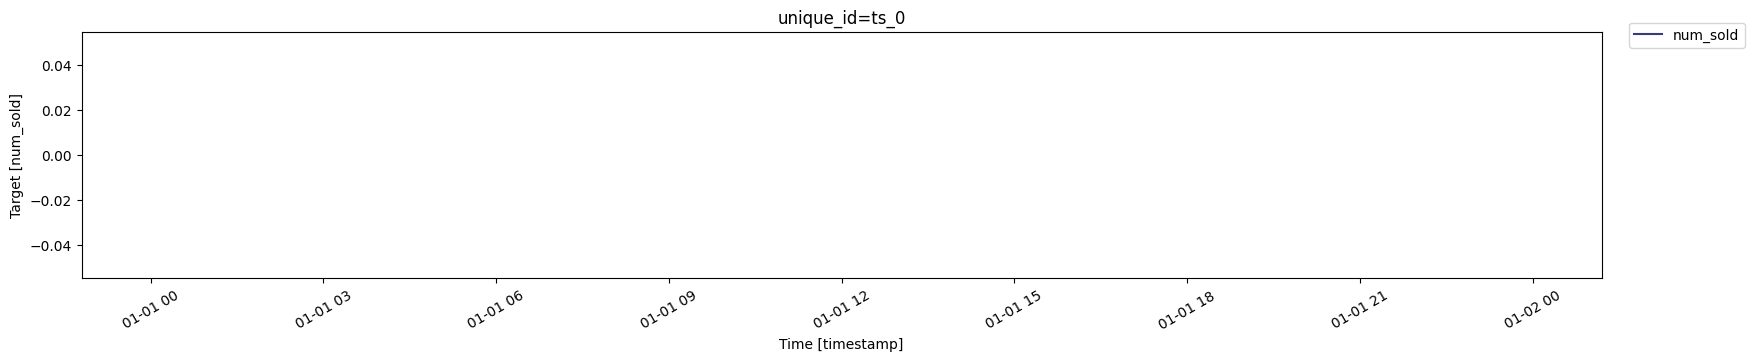

In [10]:
nixtla_client.plot(df_Canada_DS_HG, time_col='timestamp', target_col='num_sold')

In [11]:
df_Canada_DS_Kag = df_Canada_DS[df_Canada_DS['product']=='Kaggle']
df_Canada_DS_Kag

,id,timestamp,country,store,product,num_sold
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
91,91,2010-01-02,Canada,Discount Stickers,Kaggle,881.0
181,181,2010-01-03,Canada,Discount Stickers,Kaggle,1003.0
271,271,2010-01-04,Canada,Discount Stickers,Kaggle,744.0
361,361,2010-01-05,Canada,Discount Stickers,Kaggle,707.0
...,...,...,...,...,...,...
229681,229681,2016-12-27,Canada,Discount Stickers,Kaggle,694.0
229771,229771,2016-12-28,Canada,Discount Stickers,Kaggle,810.0
229861,229861,2016-12-29,Canada,Discount Stickers,Kaggle,856.0
229951,229951,2016-12-30,Canada,Discount Stickers,Kaggle,939.0


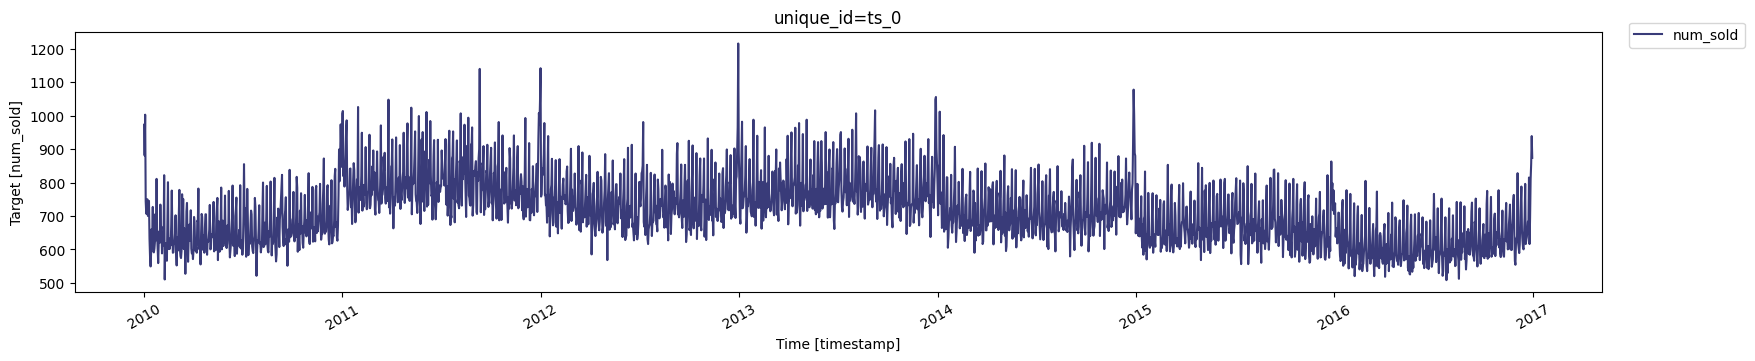

In [12]:
nixtla_client.plot(df_Canada_DS_Kag, time_col='timestamp', target_col='num_sold')

# 4 Forecasting Sales for the Next 3 years

In [17]:
timegpt_fcst_df = nixtla_client.forecast(df=df_Canada_DS_Kag, h=1095, freq='D', time_col='timestamp', target_col='num_sold', model='timegpt-1-long-horizon')
timegpt_fcst_df

INFO:nixtla.nixtla_client:Validating inputs...
/opt/miniconda3/envs/envai/lib/python3.11/site-packages/nixtla/nixtla_client.py:383: UserWarning: `df` contains the following exogenous features: ['id', 'country', 'store', 'product'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


,timestamp,TimeGPT
0,2017-01-01,872.62573
1,2017-01-02,702.98010
2,2017-01-03,684.78687
3,2017-01-04,691.62646
4,2017-01-05,696.28485
...,...,...
1090,2019-12-27,664.48126
1091,2019-12-28,692.58170
1092,2019-12-29,714.54270
1093,2019-12-30,655.65686


h: Horizons is the number of steps ahead to forecast.

https://docs.nixtla.io/docs/getting-started-timegpt_quickstart

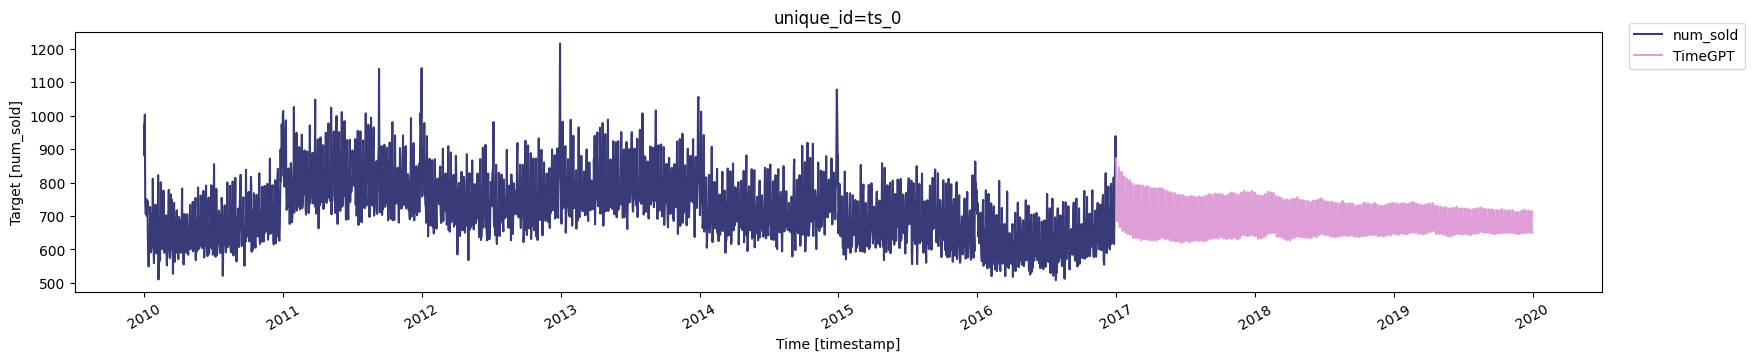

In [18]:
nixtla_client.plot(df_Canada_DS_Kag, timegpt_fcst_df, time_col='timestamp', target_col='num_sold')